# Speaker-Aware Transcription — Diarization + ASR

**Group 4 final project** — Pyannote 3.1 + faster-whisper large-v3.

**Pipeline:**
1. Diarization via `pyannote/speaker-diarization-3.1` (who spoke when)
2. Segment and label speakers from the diarization output
3. ASR via faster-whisper large-v3 (what was said), aligned word-by-word to speaker segments

**Audio:** one recording from the [VoxConverse](https://github.com/joonson/voxconverse) dev set — real multi-speaker audio with ground-truth RTTM annotations.

**Output:** speaker-labeled transcript with timestamps, plus DER, WER, RTF, and per-speaker talk time.

---

## Before you click Run All

1. **Runtime → Change runtime type → T4 GPU**
2. Accept the Pyannote model terms and paste your HuggingFace token when the token cell runs ([get a token](https://huggingface.co/settings/tokens) · [accept terms](https://hf.co/pyannote/speaker-diarization-3.1))
3. After the install cell finishes, **Runtime → Restart session**, then **Run All** again

## 1 · Install dependencies

In [ ]:
%%capture
!pip install -q pyannote.audio faster-whisper==1.0.3 jiwer==3.0.4 librosa soundfile remotezip
# After this cell: Runtime → Restart session → Run All

In [ ]:
from remotezip import RemoteZip
import shutil, os, subprocess, soundfile as sf

# VoxConverse: real multi-speaker recordings with ground-truth RTTM annotations.
# remotezip uses HTTP range requests to fetch only the central directory index
# + the one target file — the full ~500 MB zip is never downloaded.
VOXCONVERSE_FILE = 'bravd'   # ← any filename from https://github.com/joonson/voxconverse/tree/master/dev

_zip_url  = 'https://www.robots.ox.ac.uk/~vgg/data/voxconverse/data/voxconverse_dev_wav.zip'
_rttm_url = (f'https://raw.githubusercontent.com/joonson/voxconverse'
             f'/master/dev/{VOXCONVERSE_FILE}.rttm')

print(f'Fetching {VOXCONVERSE_FILE}.wav from VoxConverse dev set ...')
with RemoteZip(_zip_url) as z:
    names = z.namelist()
    match = next((n for n in names if os.path.basename(n) == f'{VOXCONVERSE_FILE}.wav'), None)
    assert match, f'{VOXCONVERSE_FILE}.wav not found. First 5 entries: {names[:5]}'
    z.extract(match, '/content/')
    src = f'/content/{match}'
    dst = f'/content/{VOXCONVERSE_FILE}.wav'
    if src != dst:
        shutil.move(src, dst)

subprocess.run(['wget', '-q', _rttm_url, '-O', f'/content/{VOXCONVERSE_FILE}.rttm'], check=True)

info = sf.info(f'/content/{VOXCONVERSE_FILE}.wav')
print(f'✓ Audio : /content/{VOXCONVERSE_FILE}.wav  ({info.duration:.1f} s, {info.samplerate} Hz)')
print(f'✓ RTTM  : /content/{VOXCONVERSE_FILE}.rttm')

Fetching bravd.wav from VoxConverse dev set ...
✓ Audio : /content/bravd.wav  (395.9 s, 16000 Hz)
✓ RTTM  : /content/bravd.rttm


## 2 · Imports and config

In [ ]:
import os, json, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import torch
warnings.filterwarnings('ignore')

print('CUDA available :', torch.cuda.is_available())
print('Device         :', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')
print('Torch version  :', torch.__version__)
print('NumPy version  :', np.__version__)
print('Pandas version :', pd.__version__)

CUDA available : True
Device         : Tesla T4
Torch version  : 2.10.0+cu128
NumPy version  : 2.4.4
Pandas version : 3.0.2


In [ ]:
INPUT_AUDIO    = f'/content/{VOXCONVERSE_FILE}.wav'
REFERENCE_RTTM = f'/content/{VOXCONVERSE_FILE}.rttm'
REFERENCE_TXT  = None
MIN_SPEAKERS   = None   # None → auto-detect via silhouette score (2–8)
MAX_SPEAKERS   = None
WHISPER_SIZE   = 'large-v3'  # 'large-v3' | 'medium' | 'small'
NO_SPEECH_THRESHOLD = 0.6
LOG_PROB_THRESHOLD  = -1.0
# ========================

OUT_DIR = Path('/content/outputs')
OUT_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_WAV = OUT_DIR / 'processed_audio.wav'

assert Path(INPUT_AUDIO).exists(), f'Audio not found: {INPUT_AUDIO}. Re-run the download cell above.'

In [ ]:
import getpass
from google.colab import userdata

# Try Colab Secrets first (Secrets panel → add key "HF_TOKEN"), then fall back to prompt.
try:
    HF_TOKEN = userdata.get('HF_TOKEN')
    print('HuggingFace token loaded from Colab Secrets.')
except Exception:
    HF_TOKEN = getpass.getpass('Paste your HuggingFace token and press Enter: ')

assert HF_TOKEN, 'Token is empty — set it in Colab Secrets or re-run this cell.'
print('Token ready.')

HuggingFace token loaded from Colab Secrets.
Token ready.


## 3 · Diarization approach

Speaker diarization uses **`pyannote/speaker-diarization-3.1`** — Pyannote's end-to-end pipeline that combines voice activity detection, speaker embedding, and clustering in one call.

- Requires a free HuggingFace account + accepting the model's terms of use (link in the intro)
- Runs on GPU automatically; falls back to CPU
- Speaker count is auto-detected; pass `min_speakers` / `max_speakers` to the pipeline call to constrain it

## 4 · Preprocess audio (16 kHz mono)

In [ ]:
import librosa, soundfile as sf

print(f'Loading {INPUT_AUDIO} ...')
y, sr = librosa.load(INPUT_AUDIO, sr=16000, mono=True)
peak = float(np.max(np.abs(y))) or 1.0
y = (y / peak) * 0.95
sf.write(str(PROCESSED_WAV), y, 16000, subtype='PCM_16')
AUDIO_DURATION = len(y) / 16000
print(f'Saved {PROCESSED_WAV}  |  {AUDIO_DURATION:.1f} s  |  16 kHz mono')

Loading /content/bravd.wav ...
Saved /content/outputs/processed_audio.wav  |  395.9 s  |  16 kHz mono


In [ ]:
with open(f'/content/{VOXCONVERSE_FILE}.rttm') as f:
    spks = {ln.split()[7] for ln in f if ln.startswith('SPEAKER')}
print('Reference speakers in RTTM:', spks)

Reference speakers in RTTM: {'spk02', 'spk01', 'spk00'}


## 5 · Diarization (Pyannote speaker-diarization-3.1)

The pipeline runs VAD → speaker embedding → agglomerative clustering in one call.
Output is a `pyannote.core.Annotation` object: an ordered set of `(Segment, track, speaker_label)` triples.

In [ ]:
from pyannote.audio import Pipeline
from pyannote.core import Annotation

print('Loading pyannote/speaker-diarization-3.1 ...')
pipeline = Pipeline.from_pretrained(
    'pyannote/speaker-diarization-3.1',
    token=HF_TOKEN,
)
pipeline.to(torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
print('Pipeline ready. Running diarization ...')

t0 = time.time()
_result = pipeline(
    str(PROCESSED_WAV),
    min_speakers=MIN_SPEAKERS,
    max_speakers=MAX_SPEAKERS,
)
DIA_TIME = round(time.time() - t0, 2)

# Unwrap DiarizeOutput → pyannote.core.Annotation
if isinstance(_result, Annotation):
    diarization = _result
else:
    diarization = _result.speaker_diarization

# Step 2: extract and label speaker segments from the diarization output
dia_segments = []
for turn, _, speaker in diarization.itertracks(yield_label=True):
    start, end = round(turn.start, 3), round(turn.end, 3)
    if dia_segments and dia_segments[-1]['speaker'] == speaker \
            and start - dia_segments[-1]['end'] < 0.3:
        dia_segments[-1]['end'] = end
        dia_segments[-1]['duration'] = round(end - dia_segments[-1]['start'], 3)
    else:
        dia_segments.append({'start': start, 'end': end,
                              'duration': round(end - start, 3), 'speaker': speaker})

speakers = sorted({s['speaker'] for s in dia_segments})
print(f'Done in {DIA_TIME}s  |  {len(dia_segments)} segments  |  {len(speakers)} speakers: {speakers}')

# Save hypothesis RTTM
rttm_path = OUT_DIR / 'diarization.rttm'
with open(rttm_path, 'w') as f:
    for seg in dia_segments:
        dur = round(seg['end'] - seg['start'], 3)
        f.write(f"SPEAKER file1 1 {seg['start']:.3f} {dur:.3f} <NA> <NA> {seg['speaker']} <NA> <NA>\n")
print(f'RTTM saved: {rttm_path}')


Loading pyannote/speaker-diarization-3.1 ...


config.yaml:   0%|          | 0.00/469 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/5.91M [00:00<?, ?B/s]

plda/xvec_transform.npz:   0%|          | 0.00/134k [00:00<?, ?B/s]

plda/plda.npz:   0%|          | 0.00/134k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/26.6M [00:00<?, ?B/s]

Pipeline ready. Running diarization ...
Done in 26.11s  |  70 segments  |  3 speakers: ['SPEAKER_00', 'SPEAKER_01', 'SPEAKER_02']
RTTM saved: /content/outputs/diarization.rttm


## 6 · ASR (faster-whisper large-v3)

First call downloads ~3 GB of model weights. Cached after that.
On T4: ~1.5 min for a 10-min clip; ~9 min for an hour.

In [ ]:
from faster_whisper import WhisperModel

print(f'Loading faster-whisper {WHISPER_SIZE} on CUDA ...')
asr_model = WhisperModel(WHISPER_SIZE, device='cuda', compute_type='float16')
print('ASR model ready. Transcribing ...')

t0 = time.time()
seg_iter, info = asr_model.transcribe(
    str(PROCESSED_WAV),
    language='en',
    beam_size=5,
    word_timestamps=True,
    vad_filter=True,
)
asr_segments, skipped = [], 0
for seg in seg_iter:
    if seg.no_speech_prob > NO_SPEECH_THRESHOLD or seg.avg_logprob < LOG_PROB_THRESHOLD:
        skipped += 1
        continue
    words = []
    if seg.words:
        for w in seg.words:
            words.append({'start': round(float(w.start), 3),
                          'end'  : round(float(w.end),   3),
                          'word' : w.word})
    asr_segments.append({
        'start'         : round(float(seg.start), 3),
        'end'           : round(float(seg.end),   3),
        'text'          : seg.text.strip(),
        'words'         : words,
        'no_speech_prob': round(float(seg.no_speech_prob), 4),
        'avg_logprob'   : round(float(seg.avg_logprob),    4),
    })
ASR_TIME = round(time.time() - t0, 2)
print(f'Done in {ASR_TIME}s  |  {len(asr_segments)} segments kept, {skipped} skipped  |  '
      f'language: {info.language} ({info.language_probability:.2f})')

Loading faster-whisper large-v3 on CUDA ...
ASR model ready. Transcribing ...
Done in 50.82s  |  88 segments kept, 0 skipped  |  language: en (1.00)


## 7 · Align ASR ↔ diarization

For every transcribed word, find the diarization segment that contains its
midpoint time. Assign that speaker. Then collapse runs of same-speaker words
into utterances.

In [ ]:
import bisect

# Build sorted arrays once for O(log n) speaker lookup per word
_starts = [s['start'] for s in dia_segments]
_ends   = [s['end']   for s in dia_segments]
_labels = [s['speaker'] for s in dia_segments]

def word_speaker(t):
    """Return the speaker whose segment contains time t (midpoint match)."""
    # Find the last segment that starts at or before t
    i = bisect.bisect_right(_starts, t) - 1
    if i >= 0 and _ends[i] >= t:
        return _labels[i]
    # Fallback: nearest segment by boundary distance
    best = min(range(len(dia_segments)),
               key=lambda j: min(abs(t - _starts[j]), abs(t - _ends[j])))
    return _labels[best]

tagged = []
for seg in asr_segments:
    if not seg['words']:
        mid = (seg['start'] + seg['end']) / 2
        tagged.append({'start': seg['start'], 'end': seg['end'],
                       'word': seg['text'], 'speaker': word_speaker(mid)})
        continue
    for w in seg['words']:
        mid = (w['start'] + w['end']) / 2
        tagged.append({'start': w['start'], 'end': w['end'],
                       'word': w['word'], 'speaker': word_speaker(mid)})

# Collapse same-speaker runs into utterances
utterances = []
if tagged:
    cur = {'start': tagged[0]['start'], 'end': tagged[0]['end'],
           'speaker': tagged[0]['speaker'], 'words': [tagged[0]['word']]}
    for w in tagged[1:]:
        if w['speaker'] == cur['speaker']:
            cur['end'] = w['end']
            cur['words'].append(w['word'])
        else:
            utterances.append({'start': round(cur['start'], 3), 'end': round(cur['end'], 3),
                               'speaker': cur['speaker'], 'text': ''.join(cur['words']).strip()})
            cur = {'start': w['start'], 'end': w['end'],
                   'speaker': w['speaker'], 'words': [w['word']]}
    utterances.append({'start': round(cur['start'], 3), 'end': round(cur['end'], 3),
                       'speaker': cur['speaker'], 'text': ''.join(cur['words']).strip()})

print(f'{len(utterances)} speaker-labeled utterances produced.')

39 speaker-labeled utterances produced.


## 8 · Post-process and save outputs

In [ ]:
import re

REPEAT = re.compile(r'\b(\w+)( \1\b)+', flags=re.IGNORECASE)

def clean(text):
    text = REPEAT.sub(r'\1', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'\s+([,.!?;:])', r'\1', text)
    return text

cleaned = []
for u in utterances:
    txt = clean(u['text'])
    if not txt:
        continue
    if (u['end'] - u['start']) < 0.3 and cleaned and cleaned[-1]['speaker'] == u['speaker']:
        cleaned[-1]['end'] = u['end']
        cleaned[-1]['text'] = (cleaned[-1]['text'] + ' ' + txt).strip()
    else:
        cleaned.append({**u, 'text': txt})

def fmt(t):
    return f'{int(t//60):02d}:{t%60:05.2f}'

lines = [f"[{fmt(u['start'])} → {fmt(u['end'])}]  {u['speaker']}:  {u['text']}" for u in cleaned]
transcript_text = '\n\n'.join(lines)

(OUT_DIR / 'speaker_transcript.txt').write_text(transcript_text)

df = pd.DataFrame([{'index': i, 'start': u['start'], 'end': u['end'],
                    'duration': round(u['end']-u['start'], 3),
                    'speaker': u['speaker'], 'text': u['text']}
                   for i, u in enumerate(cleaned)])
df.to_csv(OUT_DIR / 'segments.csv', index=False)

print(f'Saved transcript ({len(cleaned)} utterances) and segments.csv')
print('\n--- First 5 utterances ---\n')
print('\n\n'.join(lines[:5]))

Saved transcript (39 utterances) and segments.csv

--- First 5 utterances ---

[00:00.00 → 00:29.66]  SPEAKER_01:  What you're proposing, or what the President is proposing here, does not sound like it's in keeping with American tradition when it comes to immigration. The Statue of Liberty says, give me your tired, your poor, your huddled masses, yearning to breathe free. It doesn't say anything about speaking English or being able to be a computer programmer. Aren't you trying to change what it means to be an immigrant coming into this country if you're telling them you have to speak English? Can't people learn how to speak English when they get here? Well,

[00:29.82 → 00:55.64]  SPEAKER_02:  first of all, right now, it's a requirement that to be naturalized, you have to speak English. So the notion that speaking English wouldn't be a part of our immigration systems would be actually very ahistorical. Secondly, I don't want to get off into a whole thing about history here, but the St

## 9 · Evaluate

**RTF** is always reported. **DER** runs if `REFERENCE_RTTM` is set.
**WER** runs if `REFERENCE_TXT` is set.

In [ ]:
from pyannote.core import Annotation, Segment
from pyannote.metrics.diarization import DiarizationErrorRate

metrics = {
    'audio_duration_s'  : round(AUDIO_DURATION, 2),
    'diarization_time_s': DIA_TIME,
    'asr_time_s'        : ASR_TIME,
    'total_processing_s': round(DIA_TIME + ASR_TIME, 2),
    'rtf'               : round((DIA_TIME + ASR_TIME) / AUDIO_DURATION, 4),
    'num_speakers_pred' : len(speakers),
    'num_utterances'    : len(cleaned),
    'asr_language'      : info.language,
    'asr_model'         : WHISPER_SIZE,
    'avg_no_speech_prob': round(sum(s['no_speech_prob'] for s in asr_segments) / max(len(asr_segments), 1), 4),
    'avg_logprob'       : round(sum(s['avg_logprob']    for s in asr_segments) / max(len(asr_segments), 1), 4),
}

# Per-speaker stats
by_spk = {}
for u in cleaned:
    s = u['speaker']
    by_spk.setdefault(s, {'speaker': s, 'talk_time_s': 0.0, 'turns': 0, 'words': 0})
    by_spk[s]['talk_time_s'] += (u['end'] - u['start'])
    by_spk[s]['turns'] += 1
    by_spk[s]['words'] += len(u['text'].split())
metrics['per_speaker'] = sorted([{**v, 'talk_time_s': round(v['talk_time_s'], 2)}
                                  for v in by_spk.values()],
                                 key=lambda x: -x['talk_time_s'])

# DER — uses the pyannote Annotation object from the diarization pipeline directly
if REFERENCE_RTTM and Path(REFERENCE_RTTM).exists():
    ref = Annotation()
    with open(REFERENCE_RTTM) as f:
        for ln in f:
            p = ln.strip().split()
            if not p or p[0] != 'SPEAKER':
                continue
            ref[Segment(float(p[3]), float(p[3]) + float(p[4]))] = p[7]

    der = DiarizationErrorRate(collar=0.25, skip_overlap=False)(ref, diarization, detailed=True)
    total = der['total'] or 1.0
    metrics['der']              = round(der['diarization error rate'], 4)
    metrics['false_alarm']      = round(der['false alarm'] / total, 4)
    metrics['missed_detection'] = round(der['missed detection'] / total, 4)
    metrics['confusion']        = round(der['confusion'] / total, 4)

    # Speaker-turn accuracy (boundary within 0.5 s tolerance)
    true_changes, prev = set(), None
    for turn, _, spk in ref.itertracks(yield_label=True):
        if prev and prev != spk:
            true_changes.add(round(turn.start, 1))
        prev = spk
    pred_changes = {round(u['start'], 1) for u in cleaned[1:]}
    tp = len(true_changes & pred_changes)
    metrics['turn_precision'] = round(tp / max(len(pred_changes), 1), 4)
    metrics['turn_recall']    = round(tp / max(len(true_changes),  1), 4)

# WER/CER
if REFERENCE_TXT and Path(REFERENCE_TXT).exists():
    import jiwer
    ref_text = Path(REFERENCE_TXT).read_text()
    hyp_text = ' '.join(u['text'] for u in cleaned)
    norm = jiwer.Compose([jiwer.ToLowerCase(), jiwer.RemovePunctuation(),
                          jiwer.RemoveMultipleSpaces(), jiwer.Strip(),
                          jiwer.ReduceToListOfListOfWords()])
    metrics['wer'] = round(jiwer.wer(ref_text, hyp_text,
                                     truth_transform=norm, hypothesis_transform=norm), 4)
    norm_c = jiwer.Compose([jiwer.ToLowerCase(), jiwer.RemovePunctuation(),
                            jiwer.RemoveMultipleSpaces(), jiwer.Strip(),
                            jiwer.ReduceToListOfListOfChars()])
    metrics['cer'] = round(jiwer.cer(ref_text, hyp_text,
                                     truth_transform=norm_c, hypothesis_transform=norm_c), 4)

(OUT_DIR / 'metrics.json').write_text(json.dumps(metrics, indent=2))
print(json.dumps(metrics, indent=2))

{
  "audio_duration_s": 395.88,
  "diarization_time_s": 26.11,
  "asr_time_s": 50.82,
  "total_processing_s": 76.93,
  "rtf": 0.1943,
  "num_speakers_pred": 3,
  "num_utterances": 39,
  "asr_language": "en",
  "asr_model": "large-v3",
  "avg_no_speech_prob": 0.0129,
  "avg_logprob": -0.1597,
  "per_speaker": [
    {
      "speaker": "SPEAKER_02",
      "talk_time_s": 293.5,
      "turns": 19,
      "words": 935
    },
    {
      "speaker": "SPEAKER_01",
      "talk_time_s": 92.72,
      "turns": 18,
      "words": 305
    },
    {
      "speaker": "SPEAKER_00",
      "talk_time_s": 4.68,
      "turns": 2,
      "words": 15
    }
  ],
  "der": 0.0892,
  "false_alarm": 0.0081,
  "missed_detection": 0.076,
  "confusion": 0.0051,
  "turn_precision": 0.1316,
  "turn_recall": 0.1163
}


## 10 · Quick visual sanity check

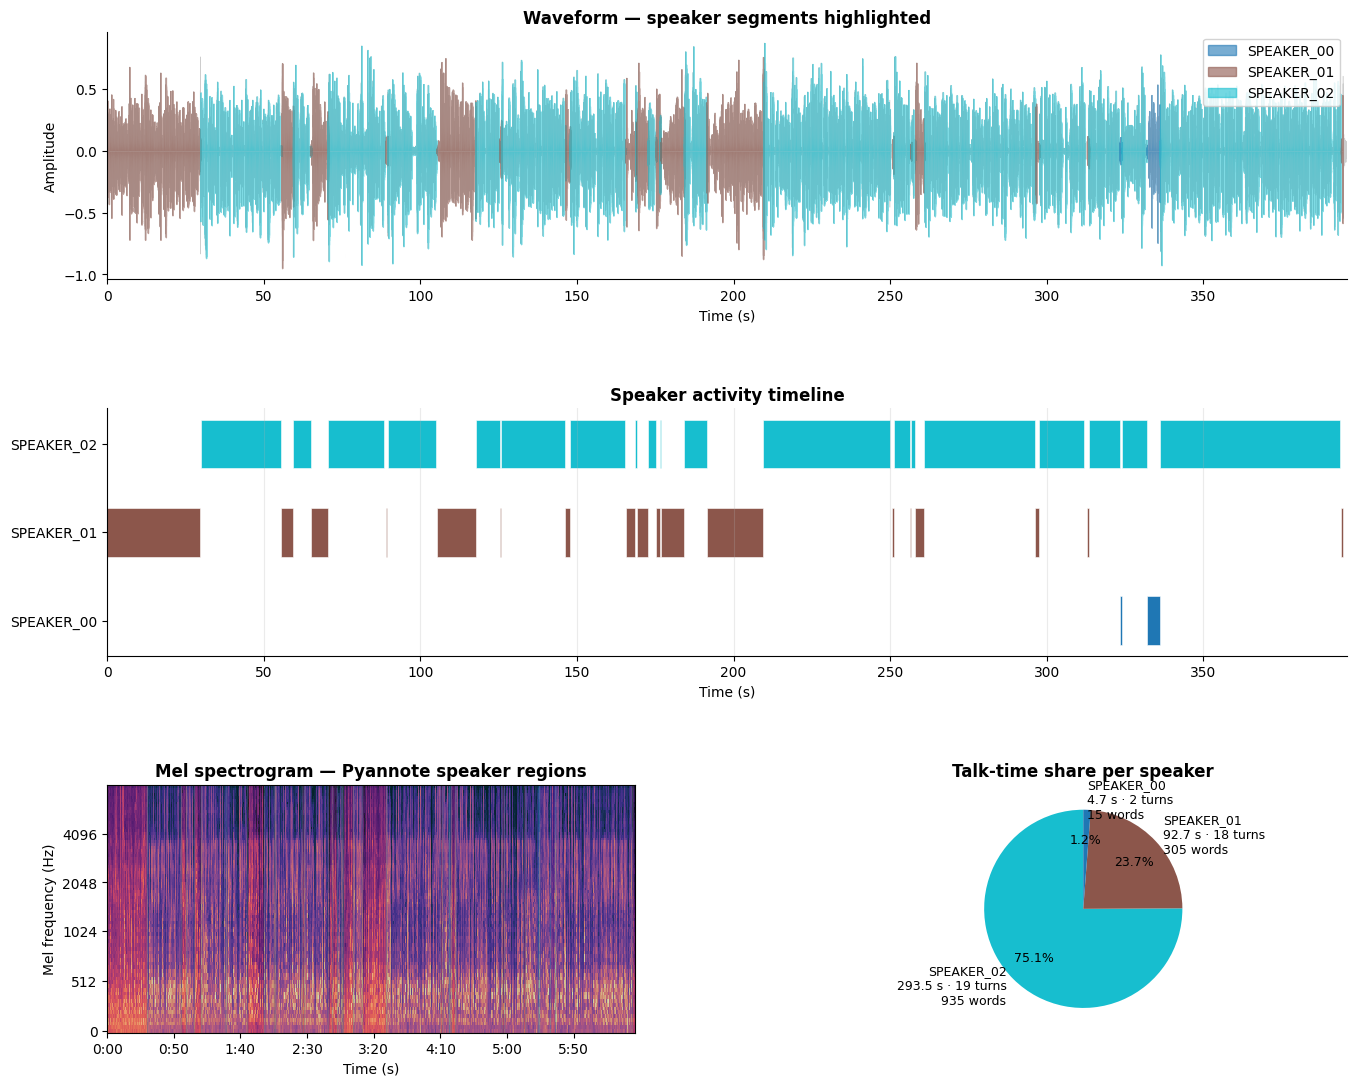

Dashboard saved → /content/outputs/dashboard.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import librosa
import librosa.display
import numpy as np

colors_arr = plt.cm.tab10(np.linspace(0, 1, max(len(speakers), 2)))
spk_color  = {s: colors_arr[i] for i, s in enumerate(speakers)}

y_wave, _ = librosa.load(str(PROCESSED_WAV), sr=16000, mono=True)
t_wave     = np.linspace(0, AUDIO_DURATION, len(y_wave))

fig = plt.figure(figsize=(16, 13))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.52, wspace=0.35)

# Panel 1 — Waveform with speaker colour overlay ──────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(t_wave, y_wave, color='#cccccc', linewidth=0.35, zorder=1)
for u in cleaned:
    m = (t_wave >= u['start']) & (t_wave <= u['end'])
    ax1.fill_between(t_wave, y_wave, 0, where=m,
                     color=spk_color[u['speaker']], alpha=0.55, zorder=2)
for spk in speakers:
    ax1.fill_between([], [], [], color=spk_color[spk], alpha=0.6, label=spk)
ax1.set_xlim(0, AUDIO_DURATION)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Amplitude')
ax1.set_title('Waveform — speaker segments highlighted', fontweight='bold', fontsize=12)
ax1.legend(loc='upper right', framealpha=0.85)
for s in ['top', 'right']: ax1.spines[s].set_visible(False)

# Panel 2 — Speaker activity timeline ────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, :])
for u in cleaned:
    y_pos = list(speakers).index(u['speaker'])
    ax2.barh(y_pos, u['end'] - u['start'], left=u['start'],
             color=spk_color[u['speaker']], edgecolor='white', linewidth=0.4, height=0.55)
ax2.set_yticks(range(len(speakers)))
ax2.set_yticklabels(speakers, fontsize=10)
ax2.set_xlabel('Time (s)')
ax2.set_title('Speaker activity timeline', fontweight='bold', fontsize=12)
ax2.set_xlim(0, AUDIO_DURATION)
ax2.grid(axis='x', alpha=0.25)
for s in ['top', 'right']: ax2.spines[s].set_visible(False)

# Panel 3 — Mel spectrogram with Pyannote speaker regions ────────────────────
ax3 = fig.add_subplot(gs[2, 0])
S    = librosa.feature.melspectrogram(y=y_wave, sr=16000, n_mels=80, fmax=8000)
S_db = librosa.power_to_db(S, ref=np.max)
librosa.display.specshow(S_db, sr=16000, hop_length=512,
                         x_axis='time', y_axis='mel', ax=ax3, cmap='magma')
for u in cleaned:
    ax3.axvspan(u['start'], u['end'], alpha=0.18, color=spk_color[u['speaker']])
ax3.set_title('Mel spectrogram — Pyannote speaker regions', fontweight='bold', fontsize=12)
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Mel frequency (Hz)')

# Panel 4 — Talk-time pie with per-speaker stats ─────────────────────────────
ax4 = fig.add_subplot(gs[2, 1])
talk_times = [v['talk_time_s'] for v in metrics['per_speaker']]
pie_labels  = [
    f"{v['speaker']}\n{v['talk_time_s']:.1f} s · {v['turns']} turns\n{v['words']} words"
    for v in metrics['per_speaker']
]
ax4.pie(talk_times, labels=pie_labels, autopct='%1.1f%%',
        colors=[spk_color[v['speaker']] for v in metrics['per_speaker']],
        startangle=90, pctdistance=0.70, textprops={'fontsize': 9})
ax4.set_title('Talk-time share per speaker', fontweight='bold', fontsize=12)

plt.savefig(OUT_DIR / 'dashboard.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'Dashboard saved → {OUT_DIR}/dashboard.png')

## 11 · Show the transcript

Final speaker-labeled output. Download from the **Files panel** (📁) at `/content/outputs/`.

In [ ]:
from IPython.display import HTML

spk_colors = {s: f'hsl({(i*137)%360}, 65%, 35%)' for i, s in enumerate(speakers)}
html = ['<div style="font-family: -apple-system, sans-serif; line-height: 1.6;">']
for u in cleaned[:50]:  # first 50 utterances inline
    c = spk_colors[u['speaker']]
    ts = f"{fmt(u['start'])} \u2192 {fmt(u['end'])}"
    html.append(
        f'<div style="margin: 8px 0; padding: 8px 12px; border-left: 3px solid {c}; background: #fafafa;">'
        f'<div style="font-size: 11px; color: #888;">{ts}</div>'
        f'<div><b style="color: {c};">{u["speaker"]}</b>: {u["text"]}</div>'
        '</div>'
    )
if len(cleaned) > 50:
    html.append(f'<p style="color:#888;">... and {len(cleaned)-50} more utterances in speaker_transcript.txt</p>')
html.append('</div>')
HTML(''.join(html))

## Done.

Files saved to `/content/outputs/`:

| File | Contents |
|---|---|
| `speaker_transcript.txt` | Human-readable speaker-labeled transcript |
| `segments.csv` | Structured data: start, end, speaker, text per utterance |
| `diarization.rttm` | Standard RTTM format for DER evaluation |
| `metrics.json` | RTF, DER, WER, per-speaker stats |
| `dashboard.png` | 4-panel visual: waveform · timeline · PCA embeddings · talk-time |

**Download:** Files panel (📁 left sidebar) → `/content/outputs/` → right-click → Download.

```python
# Or download programmatically:
from google.colab import files
files.download('/content/outputs/dashboard.png')
files.download('/content/outputs/speaker_transcript.txt')
```